In [1]:
!pip install sentence-transformers scikit-learn matplotlib

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
sentences = [

    # SPORTS
    "Football players train every morning",
    "The team won the basketball championship",
    "Cricket is popular in many countries",
    "Athletes need strength and endurance",
    "The coach prepared the team for the match",

    # TECHNOLOGY
    "Artificial intelligence is transforming industries",
    "Machine learning improves recommendation systems",
    "Cybersecurity protects digital infrastructure",
    "Cloud computing enables scalable applications",
    "Software engineers build modern applications",

    # COOKING
    "The chef prepared a delicious pasta dish",
    "Baking requires precise measurements",
    "Fresh ingredients improve food quality",
    "The recipe included vegetables and spices",
    "Cooking at home can be healthier",

    # TRAVEL
    "Tourists visited historical monuments",
    "Air travel connects different countries",
    "Hotels provide accommodation for travelers",
    "Backpacking is a popular travel style",
    "Travel guides help tourists explore cities"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

start_time = time.time()

embeddings = model.encode(sentences)

end_time = time.time()

generation_time = end_time - start_time

print("Embeddings generated successfully!")
print("Generation Time:", round(generation_time, 2), "seconds")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings generated successfully!
Generation Time: 0.35 seconds


In [5]:
tfidf = TfidfVectorizer()

tfidf_vectors = tfidf.fit_transform(sentences)

In [6]:
pairs = [

    (0, 4),   # sports
    (5, 6),   # technology
    (10, 14), # cooking
    (15, 19), # travel
    (5, 9)    # tech
]

for i, j in pairs:

    tfidf_score = cosine_similarity(
        tfidf_vectors[i],
        tfidf_vectors[j]
    )[0][0]

    embedding_score = cosine_similarity(
        [embeddings[i]],
        [embeddings[j]]
    )[0][0]

    print("=" * 60)

    print("Sentence 1:", sentences[i])
    print("Sentence 2:", sentences[j])

    print("\nTF-IDF Similarity:",
          round(tfidf_score, 4))

    print("Embedding Similarity:",
          round(embedding_score, 4))

    print()

Sentence 1: Football players train every morning
Sentence 2: The coach prepared the team for the match

TF-IDF Similarity: 0.0
Embedding Similarity: 0.3636

Sentence 1: Artificial intelligence is transforming industries
Sentence 2: Machine learning improves recommendation systems

TF-IDF Similarity: 0.0
Embedding Similarity: 0.1916

Sentence 1: The chef prepared a delicious pasta dish
Sentence 2: Cooking at home can be healthier

TF-IDF Similarity: 0.0
Embedding Similarity: 0.3276

Sentence 1: Tourists visited historical monuments
Sentence 2: Travel guides help tourists explore cities

TF-IDF Similarity: 0.1712
Embedding Similarity: 0.4948

Sentence 1: Artificial intelligence is transforming industries
Sentence 2: Software engineers build modern applications

TF-IDF Similarity: 0.0
Embedding Similarity: 0.2935



In [7]:
paraphrase_pairs = [

    (
        "Artificial intelligence is transforming industries",
        "AI is changing how businesses operate"
    ),

    (
        "Football players train every morning",
        "Athletes practice daily for sports competitions"
    ),

    (
        "Cooking at home can be healthier",
        "Homemade meals improve personal health"
    ),

    (
        "Air travel connects different countries",
        "Flights allow people to move internationally"
    ),

    (
        "Cybersecurity protects digital infrastructure",
        "Online systems require protection from hackers"
    )
]

tfidf = TfidfVectorizer()

for s1, s2 in paraphrase_pairs:

    tfidf_matrix = tfidf.fit_transform([s1, s2])

    tfidf_score = cosine_similarity(
        tfidf_matrix[0],
        tfidf_matrix[1]
    )[0][0]

    emb1 = model.encode([s1])[0]
    emb2 = model.encode([s2])[0]

    embedding_score = cosine_similarity(
        [emb1],
        [emb2]
    )[0][0]

    print("=" * 70)

    print("Sentence 1:", s1)
    print("Sentence 2:", s2)

    print("\nTF-IDF Score:",
          round(tfidf_score, 4))

    print("Embedding Score:",
          round(embedding_score, 4))

    print()

Sentence 1: Artificial intelligence is transforming industries
Sentence 2: AI is changing how businesses operate

TF-IDF Score: 0.1016
Embedding Score: 0.7488

Sentence 1: Football players train every morning
Sentence 2: Athletes practice daily for sports competitions

TF-IDF Score: 0.0
Embedding Score: 0.5751

Sentence 1: Cooking at home can be healthier
Sentence 2: Homemade meals improve personal health

TF-IDF Score: 0.0
Embedding Score: 0.6175

Sentence 1: Air travel connects different countries
Sentence 2: Flights allow people to move internationally

TF-IDF Score: 0.0
Embedding Score: 0.6071

Sentence 1: Cybersecurity protects digital infrastructure
Sentence 2: Online systems require protection from hackers

TF-IDF Score: 0.0
Embedding Score: 0.6032



In [8]:
def embed_and_recommend(query_sentence,
                        corpus_sentences,
                        top_k=3):

    query_embedding = model.encode([query_sentence])[0]

    similarities = cosine_similarity(
        [query_embedding],
        embeddings
    )[0]

    top_indices = similarities.argsort()[::-1][:top_k]

    results = []

    for idx in top_indices:

        results.append({
            "sentence": corpus_sentences[idx],
            "score": round(float(similarities[idx]), 4)
        })

    return results

In [ ]:
query = "AI systems improve business operations"

results = embed_and_recommend(
    query,
    sentences
)

for result in results:

    print(result)

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(embeddings)

for sentence, cluster in zip(sentences, clusters):

    print(f"Cluster {cluster}: {sentence}")

Cluster 2: Football players train every morning
Cluster 3: The team won the basketball championship
Cluster 2: Cricket is popular in many countries
Cluster 2: Athletes need strength and endurance
Cluster 2: The coach prepared the team for the match
Cluster 0: Artificial intelligence is transforming industries
Cluster 1: Machine learning improves recommendation systems
Cluster 0: Cybersecurity protects digital infrastructure
Cluster 0: Cloud computing enables scalable applications
Cluster 0: Software engineers build modern applications
Cluster 3: The chef prepared a delicious pasta dish
Cluster 3: Baking requires precise measurements
Cluster 3: Fresh ingredients improve food quality
Cluster 3: The recipe included vegetables and spices
Cluster 3: Cooking at home can be healthier
Cluster 1: Tourists visited historical monuments
Cluster 1: Air travel connects different countries
Cluster 1: Hotels provide accommodation for travelers
Cluster 1: Backpacking is a popular travel style
Cluster 1

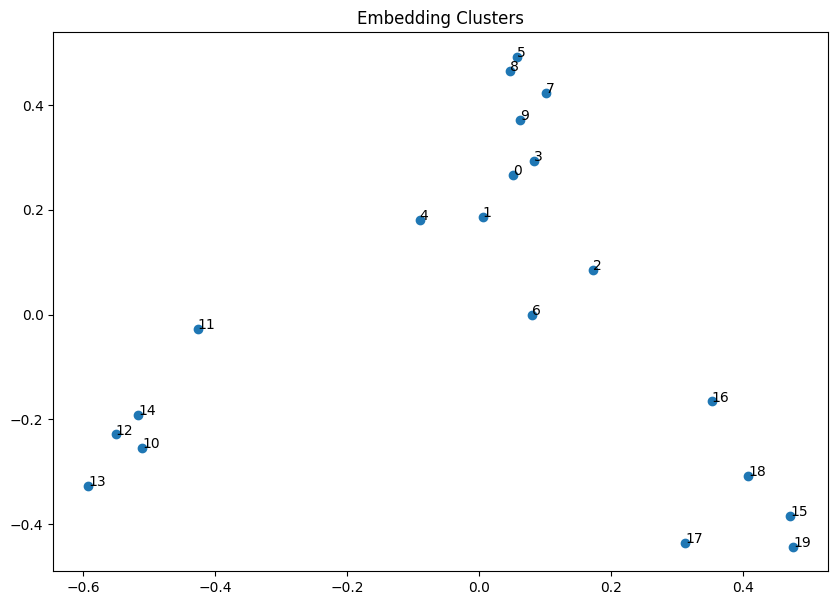

In [10]:
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))

plt.scatter(
    reduced_embeddings[:, 0],
    reduced_embeddings[:, 1]
)

for i, sentence in enumerate(sentences):

    plt.annotate(
        str(i),
        (reduced_embeddings[i, 0],
         reduced_embeddings[i, 1])
    )

plt.title("Embedding Clusters")
plt.show()

In [11]:
estimated_cost = 0

print("Embedding Generation Time:",
      round(generation_time, 2),
      "seconds")

print("Estimated API Cost: $",
      estimated_cost)

Embedding Generation Time: 0.35 seconds
Estimated API Cost: $ 0


In [12]:
print("""

TF-IDF vectors are sparse vectors based on exact word frequency.

They only capture vocabulary overlap and cannot understand semantic meaning.

Embeddings are dense vectors that encode semantic relationships between words and sentences.

This allows embeddings to generalize across different vocabulary while preserving meaning.

Example:
- "car"
- "vehicle"

TF-IDF treats them as unrelated words.

Embeddings place them close together in vector space because they have similar meanings.

This is why embeddings power modern semantic search and retrieval systems.

""")



TF-IDF vectors are sparse vectors based on exact word frequency.

They only capture vocabulary overlap and cannot understand semantic meaning.

Embeddings are dense vectors that encode semantic relationships between words and sentences.

This allows embeddings to generalize across different vocabulary while preserving meaning.

Example:
- "car"
- "vehicle"

TF-IDF treats them as unrelated words.

Embeddings place them close together in vector space because they have similar meanings.

This is why embeddings power modern semantic search and retrieval systems.


